# Base pseudo-code

In [35]:
import torch
from torch import nn, optim

def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi):
    model_t = f_theta_0
    theta_0 = [param.clone().detach() for param in f_theta_0.parameters()]
    mu = [torch.zeros_like(param, requires_grad=True) for param in theta_0]
    criterion = nn.KLDivLoss()
    optimizer = optim.LBFGS(mu, lr=eta_mu)

    for _ in range(T):
        with torch.no_grad():
            for param, theta, m in zip(model_t.parameters(), theta_0, mu):
                param.copy_((theta - xi * m).detach())

        upsilon = model_t(D_f)
        loss = criterion(upsilon, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu)

        loss.backward()
        optimizer.step()

    return model_t



# Code

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.stateless import functional_call
import copy
import random
import matplotlib.pyplot as plt


In [53]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


In [54]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [55]:
def train_model(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [56]:
def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []  # List to store the loss values

    def closure():
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        loss_history.append(loss.item())  # Store the loss value for each iteration
        print(f"Loss: {loss.item()}")
        return loss

    # Optimization loop
    for _ in range(T):
        optimizer.step(closure)

    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
        param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    # Plot the loss over iterations
    plt.plot(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss during Forsaken Optimization')
    plt.show()

    return model_t


In [57]:
def forget_set(train_dataset):
    forget_indices = random.sample(range(len(train_dataset)), 100)
    D_f = Subset(train_dataset, forget_indices)
    print(f"Nombre de points dans D_f à forget : {len(D_f)}")
    forget_loader = DataLoader(D_f, batch_size=64, shuffle=False)
    return forget_loader, D_f


In [58]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

# Execution

In [59]:
model = FullyConnectedNN()
train_model(model,  train_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7761
Epoch 2/5, Loss: 0.2989
Epoch 3/5, Loss: 0.2426
Epoch 4/5, Loss: 0.2055
Epoch 5/5, Loss: 0.1776


Nombre de points dans D_f à forget : 100
Loss: 5.802440166473389
Loss: 4.6048903465271
Loss: 3.6424875259399414
Loss: 2.8726587295532227
Loss: 2.2624571323394775
Loss: 1.7783763408660889
Loss: 1.4019609689712524
Loss: 1.1143401861190796
Loss: 0.8941007256507874
Loss: 0.7262917757034302
Loss: 0.5984795689582825
Loss: 0.5008358359336853


C:\Users\mathi\AppData\Local\Temp\ipykernel_10952\560380032.py:17: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Loss: 0.4254632592201233
Loss: 0.3662537634372711
Loss: 0.3187856376171112
Loss: 0.27999261021614075
Loss: 0.2482120245695114
Loss: 0.22191765904426575
Loss: 0.19989699125289917
Loss: 0.1810482293367386
Loss: 0.1649206131696701
Loss: 0.15122203528881073
Loss: 0.139454185962677
Loss: 0.12915848195552826
Loss: 0.12010790407657623
Loss: 0.11207205057144165
Loss: 0.1049094945192337
Loss: 0.09852410107851028
Loss: 0.09281611442565918
Loss: 0.08764266222715378
Loss: 0.08300633728504181
Loss: 0.07882193475961685
Loss: 0.07503799349069595
Loss: 0.0716089978814125
Loss: 0.06846210360527039
Loss: 0.06554130464792252
Loss: 0.06284216046333313
Loss: 0.060309480875730515
Loss: 0.057943884283304214
Loss: 0.0557379350066185
Loss: 0.05366198718547821
Loss: 0.05169949308037758
Loss: 0.049867935478687286
Loss: 0.04814877733588219
Loss: 0.04654594138264656
Loss: 0.045031026005744934
Loss: 0.04359894618391991
Loss: 0.04224381595849991
Loss: 0.04095753654837608
Loss: 0.03973246365785599
Loss: 0.03857318684

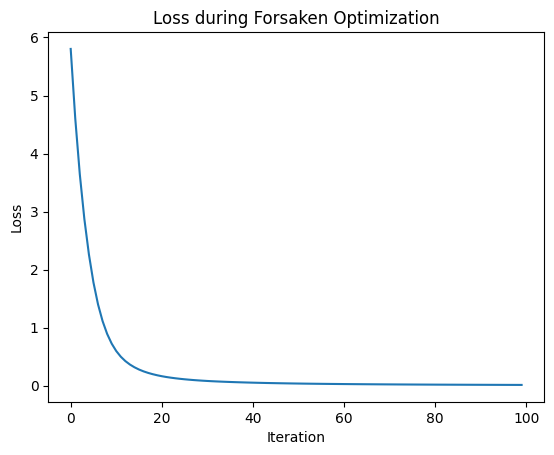

In [66]:
forget_loader, D_f = forget_set(train_dataset)
images_forget, labels_forget = next(iter(forget_loader))

P = torch.full((images_forget.size(0), 10), 1/10)

T = 100
lambda_ = 0
omega = 1.0
eta_mu = 0.1
xi = 0.5

model_forsaken = forsaken(
    f_theta_0=model,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'SGD'
)


In [67]:

accuracy_forget = evaluate_model(model_forsaken, forget_loader)
print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

accuracy_base = evaluate_model(model, forget_loader)
print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

accuracy_forget_test = evaluate_model(model_forsaken, test_loader)
print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

accuracy_base_test = evaluate_model(model, test_loader)
print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")


Accuracy sur D_f après Forsaken : 49.00%
Accuracy sur D_f sans Forsaken : 91.00%
Accuracy sur base de test après Forsaken : 69.21%
Accuracy sur base de test sans Forsaken : 95.04%


### Gaussian Poisoning

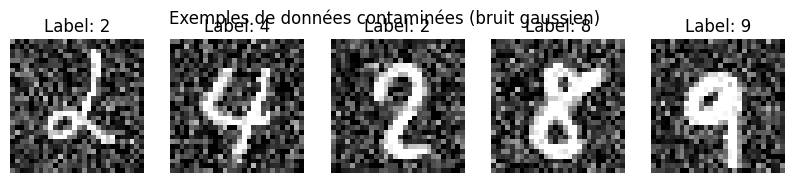

In [105]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

# Configuration
contamination_ratio = 0.6
subset_size = 10000  # Limiter à 10 000 images pour éviter surcharge mémoire

# Load MNIST (transform pas appliqué ici)
raw_dataset = datasets.MNIST(root="./data", train=True, download=True)
raw_images = raw_dataset.data[:subset_size].float() / 255.0
raw_labels = raw_dataset.targets[:subset_size]

# Déterminer les indices contaminés
num_total = len(raw_images)
num_contaminated = int(num_total * contamination_ratio)
contaminated_indices = random.sample(range(num_total), num_contaminated)
clean_indices = list(set(range(num_total)) - set(contaminated_indices))

# Fonction d'ajout de bruit
def add_gaussian_noise(images, mean=0.2, std=0.2):
    noise = torch.randn_like(images) * std + mean
    return torch.clamp(images + noise, 0.0, 1.0)

# Appliquer le bruit uniquement sur les images contaminées
contaminated_images = add_gaussian_noise(raw_images[contaminated_indices])
clean_images = raw_images[clean_indices]

# Normalisation manuelle
contaminated_images = (contaminated_images - 0.1307) / 0.3081
clean_images = (clean_images - 0.1307) / 0.3081

# Ajouter la dimension canal
contaminated_images = contaminated_images.unsqueeze(1)
clean_images = clean_images.unsqueeze(1)

# Fusion des datasets
train_images = torch.cat([clean_images, contaminated_images], dim=0)
train_labels = torch.cat([raw_labels[clean_indices], raw_labels[contaminated_indices]], dim=0)

# Création des dataloaders
noisy_train_dataset = TensorDataset(train_images, train_labels)
noisy_train_loader = DataLoader(noisy_train_dataset, batch_size=64, shuffle=True)

# Forget set = uniquement les contaminés
forget_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
forget_loader = DataLoader(forget_dataset, batch_size=64, shuffle=False)

# Affichage de quelques exemples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(contaminated_images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {raw_labels[contaminated_indices[i]].item()}")
    axes[i].axis('off')
plt.suptitle("Exemples de données contaminées (bruit gaussien)")
plt.show()


In [106]:
model_noise = FullyConnectedNN()
train_model(model_noise, train_loader=noisy_train_loader, lr=0.01, epochs=25)


Epoch 1/25, Loss: 2.0213
Epoch 2/25, Loss: 1.0823
Epoch 3/25, Loss: 0.6290
Epoch 4/25, Loss: 0.4847
Epoch 5/25, Loss: 0.4173
Epoch 6/25, Loss: 0.3728
Epoch 7/25, Loss: 0.3447
Epoch 8/25, Loss: 0.3228
Epoch 9/25, Loss: 0.3045
Epoch 10/25, Loss: 0.2887
Epoch 11/25, Loss: 0.2745
Epoch 12/25, Loss: 0.2603
Epoch 13/25, Loss: 0.2495
Epoch 14/25, Loss: 0.2379
Epoch 15/25, Loss: 0.2274
Epoch 16/25, Loss: 0.2164
Epoch 17/25, Loss: 0.2066
Epoch 18/25, Loss: 0.1967
Epoch 19/25, Loss: 0.1889
Epoch 20/25, Loss: 0.1805
Epoch 21/25, Loss: 0.1722
Epoch 22/25, Loss: 0.1634
Epoch 23/25, Loss: 0.1559
Epoch 24/25, Loss: 0.1486
Epoch 25/25, Loss: 0.1426


In [107]:
forget_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
forget_loader = DataLoader(forget_dataset, batch_size=64, shuffle=False)

# On prend un batch du forget set pour le test
images_forget, labels_forget = next(iter(forget_loader))

# P = distribution uniforme cible
P = torch.full((images_forget.size(0), 10), 1/10)


C:\Users\mathi\AppData\Local\Temp\ipykernel_10952\560380032.py:17: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Loss: 7.263974189758301
Loss: 7.2447357177734375
Loss: 4.260101795196533
Loss: 3.2894437313079834
Loss: 2.4212167263031006
Loss: 1.7800894975662231
Loss: 1.3690416812896729
Loss: 1.0644179582595825
Loss: 0.7985745072364807
Loss: 0.5835450291633606
Loss: 0.4077911078929901
Loss: 0.2744767665863037
Loss: 0.1790204644203186
Loss: 0.11738462746143341
Loss: 0.08112159371376038
Loss: 0.05966680496931076
Loss: 0.04731171205639839
Loss: 0.037826474756002426
Loss: 0.029957391321659088
Loss: 0.02257116511464119
Loss: 0.01753918081521988
Loss: 0.013948826119303703
Loss: 0.010428323410451412
Loss: 0.00827980600297451
Loss: 0.006540259812027216
Loss: 0.005412780214101076
Loss: 0.004481127951294184
Loss: 0.003640906186774373
Loss: 0.002955665113404393
Loss: 0.00253749149851501
Loss: 0.0020941030234098434
Loss: 0.0016936678439378738
Loss: 0.0014525637961924076
Loss: 0.0012659074272960424
Loss: 0.0009820552077144384
Loss: 0.0008478241506963968
Loss: 0.0007426280062645674
Loss: 0.00065195607021451
Loss

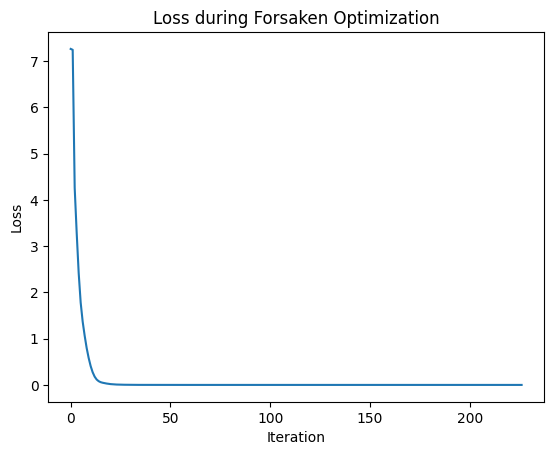

In [108]:
T = 100
lambda_ = 0
omega = 1.0
eta_mu = 0.2
xi = 3.0

model_forsaken_noise = forsaken(
    f_theta_0=model_noise,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,  # batch d’images à oublier
    eta_mu=eta_mu,
    xi=xi,
    optimizer='LBFGS'
)


In [109]:
# Évaluer le modèle après Forsaken sur le forget set
accuracy_forget_noise = evaluate_model(model_forsaken_noise, forget_loader)
print(f"🔁 Accuracy sur D_f après Forsaken : {accuracy_forget_noise:.2f}%")

# Évaluer le modèle initial (model_noise) sur le forget set
accuracy_base_noise = evaluate_model(model_noise, forget_loader)
print(f"🎯 Accuracy sur D_f sans Forsaken : {accuracy_base_noise:.2f}%")

# Évaluer sur le test set standard
accuracy_forget_test = evaluate_model(model_forsaken_noise, test_loader)
print(f"🧪 Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

accuracy_base_test = evaluate_model(model_noise, test_loader)
print(f"✅ Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")


🔁 Accuracy sur D_f après Forsaken : 48.35%
🎯 Accuracy sur D_f sans Forsaken : 96.93%
🧪 Accuracy sur base de test après Forsaken : 58.48%
✅ Accuracy sur base de test sans Forsaken : 92.42%
